### 06 Align plaques TIFF image to Xenium coordinates -- copy with my codes

This notebook aligns `morphology.ome.tiff` to the Xenium spatial coordinates in `05_scvi.h5ad`, writes QC overlays, optionally applies manual landmark correction, segments plaque-like signal, and assigns each cell to its nearest plaque.

Run the cells from top to bottom. After the first run, inspect `qc_initial_morphology_xenium_overlay.png`, `qc_final_morphology_xenium_overlay.png`, and `qc_plaque_segmentation.png` in the working directory. If the overlay needs correction, fill the generated `manual_landmarks.csv` and rerun the landmark/alignment cells.

In [24]:
from importlib.machinery import SourceFileLoader
import json
import os
import sys
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Any
import tifffile as tiff # type: ignore
import matplotlib.pyplot as plt # type: ignore
import numpy as np
import pandas as pd # type: ignore
import scanpy as sc # type: ignore
from scipy.spatial import cKDTree # type: ignore
from skimage.filters import gaussian, threshold_otsu # type: ignore
from skimage.measure import label, regionprops_table # type: ignore
from skimage.morphology import (
    binary_closing,
    binary_opening,
    disk,
    remove_small_holes,
    remove_small_objects,
) # type: ignore
from skimage.transform import AffineTransform, estimate_transform # type: ignore
import importlib.util
import sys
from pathlib import Path

module_path = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex/06_plaques_alignment.py")
sys.modules.pop("plaques_alignment", None)

spec = importlib.util.spec_from_file_location("plaques_alignment", module_path)
plaques_alignment = importlib.util.module_from_spec(spec)
sys.modules["plaques_alignment"] = plaques_alignment
spec.loader.exec_module(plaques_alignment)

print("Loaded:", plaques_alignment)



Loaded: <module 'plaques_alignment' from '/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex/06_plaques_alignment.py'>


In [25]:
WORKING_DIRECTORY = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment")
MORPHOLOGY_PATH = Path('/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif').expanduser()

z_dir = WORKING_DIRECTORY / "morphology_z_plane_checks"
z_dir.mkdir(parents=True, exist_ok=True)

def robust_rescale(img, lower=1, upper=99.8):
    img = img.astype(float, copy=False)
    lo, hi = np.nanpercentile(img, [lower, upper])

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(img, dtype=float)

    return np.clip((img - lo) / (hi - lo), 0, 1)


z_dir = WORKING_DIRECTORY / "morphology_z_plane_checks"
z_dir.mkdir(parents=True, exist_ok=True)

with tiff.TiffFile(MORPHOLOGY_PATH) as tif:
    series = tif.series[0]
    levels = getattr(series, "levels", None) or [series]
    level = levels[min(2, len(levels) - 1)]
    arr = level.asarray()

print(arr.shape)

for z in range(arr.shape[0]):
    img = arr[z, :, :]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(robust_rescale(img), cmap="gray", origin="upper")
    ax.set_title(f"Z plane {z}")
    ax.axis("off")

    out = z_dir / f"z_plane_{z:02d}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig)

    print(out)
    

(13, 7681, 9968)
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/morphology_z_plane_checks/z_plane_00.png
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/morphology_z_plane_checks/z_plane_01.png
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/morphology_z_plane_checks/z_plane_02.png
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAE

### Load the APPS/PS1 infected and APPS/PS1 mock separately

In [26]:
WORKING_DIRECTORY = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment")
INPUT_DIR = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI")
MORPHOLOGY_PATH = Path('/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif').expanduser()

H5AD_PATH = INPUT_DIR / "05_scvi.h5ad"
ALIGNED_H5AD_PATH = WORKING_DIRECTORY / "05_scvi_with_morphology_alignment.h5ad"
PLAQUE_H5AD_PATH = WORKING_DIRECTORY / "05_scvi_with_plaque_distances.h5ad"
LANDMARK_TEMPLATE_PATH = WORKING_DIRECTORY / "manual_landmarks_template.csv"
LANDMARK_PATH = WORKING_DIRECTORY / "manual_landmarks.csv"

WORKING_DIRECTORY.mkdir(parents=True, exist_ok=True)
os.chdir(WORKING_DIRECTORY)

print(f"Working directory: {Path.cwd()}")
print(f"Input h5ad: {H5AD_PATH}")
print(f"Morphology image: {MORPHOLOGY_PATH}")

assert H5AD_PATH.exists(), f"Missing h5ad: {H5AD_PATH}"
assert MORPHOLOGY_PATH.exists(), f"Missing morphology image: {MORPHOLOGY_PATH}"

Working directory: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment
Input h5ad: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI/05_scvi.h5ad
Morphology image: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif


### Settings to tune

In [27]:
COORDINATE_UNITS = "micron"

DISPLAY_LEVEL = 2
PLAQUE_CHANNEL_INDEX = None
RUN_PLAQUE_SEGMENTATION = True

PLAQUE_THRESHOLD_MODE = "absolute"
PLAQUE_ABSOLUTE_THRESHOLD = 2975.0
PLAQUE_SMOOTH_SIGMA = 0.0
PLAQUE_THRESHOLD_MULTIPLIER = 1.0
MIN_PLAQUE_AREA_UM2 = 25.0
MAX_HOLE_AREA_UM2 = 25.0
PLAQUE_OPENING_RADIUS_PX = 1
PLAQUE_CLOSING_RADIUS_PX = 2

PLAQUE_NEIGHBOR_RADIUS = 50

LANDMARK_TRANSFORM_TYPE = "similarity"


In [28]:

module_globals = [
    "WORKING_DIRECTORY",
    "MORPHOLOGY_PATH",
    "H5AD_PATH",
    "ALIGNED_H5AD_PATH",
    "PLAQUE_H5AD_PATH",
    "LANDMARK_TEMPLATE_PATH",
    "LANDMARK_PATH",
    "COORDINATE_UNITS",
    "LANDMARK_TRANSFORM_TYPE",
    "MIN_PLAQUE_AREA_UM2",
    "MAX_HOLE_AREA_UM2",
    "PLAQUE_THRESHOLD_MODE",
    "PLAQUE_ABSOLUTE_THRESHOLD",
    "PLAQUE_SMOOTH_SIGMA",
    "PLAQUE_THRESHOLD_MULTIPLIER",
    "PLAQUE_OPENING_RADIUS_PX",
    "PLAQUE_CLOSING_RADIUS_PX",
    "PLAQUE_NEIGHBOR_RADIUS",
]

for name in module_globals:
    if name in globals():
        setattr(plaques_alignment, name, globals()[name])
    else:
        print(f"Missing in notebook: {name}")

# Override the imported helper so plaque detection matches the Xenium Explorer
# raw intensity threshold used in the screenshot.
def segment_plaques_raw_threshold(
    plaque_img: np.ndarray,
    image_to_xenium_transform: Any,
    ome_meta: dict[str, Any],
    level_info: dict[str, Any],
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    physical_size_x = float(ome_meta["physical_size_x"])
    physical_size_y = float(ome_meta["physical_size_y"])
    pixel_area_um2 = (
        physical_size_x
        * physical_size_y
        * float(level_info["downsample_x"])
        * float(level_info["downsample_y"])
    )
    min_area_px = max(1, int(np.ceil(MIN_PLAQUE_AREA_UM2 / pixel_area_um2)))
    hole_area_px = max(1, int(np.ceil(MAX_HOLE_AREA_UM2 / pixel_area_um2)))

    plaque_values = plaque_img.astype(float, copy=False)
    if PLAQUE_THRESHOLD_MODE == "absolute":
        threshold = float(PLAQUE_ABSOLUTE_THRESHOLD)
        mask = plaque_values >= threshold
    elif PLAQUE_THRESHOLD_MODE == "otsu":
        if PLAQUE_SMOOTH_SIGMA and PLAQUE_SMOOTH_SIGMA > 0:
            threshold_img = gaussian(plaque_values, sigma=PLAQUE_SMOOTH_SIGMA, preserve_range=True)
        else:
            threshold_img = plaque_values
        threshold = threshold_otsu(threshold_img) * PLAQUE_THRESHOLD_MULTIPLIER
        mask = threshold_img > threshold
    else:
        raise ValueError('PLAQUE_THRESHOLD_MODE must be "absolute" or "otsu".')

    if PLAQUE_OPENING_RADIUS_PX and PLAQUE_OPENING_RADIUS_PX > 0:
        mask = binary_opening(mask, disk(PLAQUE_OPENING_RADIUS_PX))
    if PLAQUE_CLOSING_RADIUS_PX and PLAQUE_CLOSING_RADIUS_PX > 0:
        mask = binary_closing(mask, disk(PLAQUE_CLOSING_RADIUS_PX))
    mask = remove_small_objects(mask, min_size=min_area_px)
    mask = remove_small_holes(mask, area_threshold=hole_area_px)

    print(
        f"Plaque threshold mode: {PLAQUE_THRESHOLD_MODE}; "
        f"threshold={threshold:.3f}; min_area_px={min_area_px}; "
        f"candidate_pixels={int(mask.sum())}"
    )

    labels = label(mask)
    props = pd.DataFrame(
        regionprops_table(
            labels,
            intensity_image=plaque_img,
            properties=["label", "area", "centroid", "bbox", "mean_intensity", "max_intensity"],
        )
    )

    if props.empty:
        return props, mask, labels

    props = props.rename(
        columns={"centroid-0": "centroid_y_level_px", "centroid-1": "centroid_x_level_px"}
    )
    props["plaque_id"] = props["label"].astype(int)
    props["area_um2"] = props["area"] * pixel_area_um2
    props["threshold_mode"] = PLAQUE_THRESHOLD_MODE
    props["threshold"] = float(threshold)

    fullres_xy = plaques_alignment.level_to_fullres_points(
        props[["centroid_x_level_px", "centroid_y_level_px"]].to_numpy(float),
        tuple(ome_meta["fullres_shape_yx"]),
        (int(level_info["height_px"]), int(level_info["width_px"])),
    )
    props["centroid_x_fullres_px"] = fullres_xy[:, 0]
    props["centroid_y_fullres_px"] = fullres_xy[:, 1]

    xenium_xy = image_to_xenium_transform(fullres_xy)
    props["x_xenium"] = xenium_xy[:, 0]
    props["y_xenium"] = xenium_xy[:, 1]
    return props, mask, labels


def plot_plaque_segmentation_raw_threshold(
    plaque_img: np.ndarray,
    mask: np.ndarray,
    plaque_df: pd.DataFrame,
    output_path: Path,
) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(plaques_alignment.robust_rescale(plaque_img), cmap="gray", origin="upper")
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.45, origin="upper")
    if mask.any():
        ax.contour(mask.astype(float), levels=[0.5], colors="cyan", linewidths=0.35)
    if not plaque_df.empty:
        ax.scatter(
            plaque_df["centroid_x_level_px"],
            plaque_df["centroid_y_level_px"],
            s=12,
            c="lime",
            edgecolors="black",
            linewidths=0.4,
        )
    ax.set_xlim(0, plaque_img.shape[1])
    ax.set_ylim(plaque_img.shape[0], 0)
    ax.set_aspect("equal")
    ax.set_title(f"Plaque segmentation: {PLAQUE_THRESHOLD_MODE} threshold {PLAQUE_ABSOLUTE_THRESHOLD:g}")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()
    print(f"Saved: {output_path}")

plaques_alignment.segment_plaques = segment_plaques_raw_threshold
plaques_alignment.plot_plaque_segmentation = plot_plaque_segmentation_raw_threshold
print(f"Using plaque intensity threshold: {PLAQUE_ABSOLUTE_THRESHOLD:g}")



## Load xenium object and coordinates

In [ ]:
adata = sc.read_h5ad(H5AD_PATH)
xenium_xy, coordinate_source = plaques_alignment.get_xenium_coordinates(adata)
adata.obsm["xenium_xy"] = xenium_xy[["x", "y"]].to_numpy(float)

print(adata)
print(f"Coordinate source: {coordinate_source}")
print(
    "Coordinate ranges: "
    f"x={xenium_xy['x'].min():.2f}..{xenium_xy['x'].max():.2f}, "
    f"y={xenium_xy['y'].min():.2f}..{xenium_xy['y'].max():.2f}"
)
print("obsm keys:", list(adata.obsm.keys()))


AnnData object with n_obs × n_vars = 158112 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5', 'Topic 6', 'Topic 7', 'Topic 8', 'Topic 9', 'Topic 10', 'Topic 11', 'Topic 12', 'Topic 13', 'Topic 14', 'Topic 15', 'topic', 'batch', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bad_tissue_filtering', 'batch_colors', 'filtering_downsize', 'filtering_image_padding', 'initial_neighborhood_parameters', 'leiden', 'leiden_colors', 'scvi', 'scvi_inp

### Inspect morphology image and read display levle

In [30]:
ome_meta = plaques_alignment.inspect_ome_tiff(MORPHOLOGY_PATH)
if ome_meta.get("physical_size_x") is None or ome_meta.get("physical_size_y") is None:
    raise ValueError(
        "OME metadata does not contain PhysicalSizeX/Y. "
        "Provide pixel size before converting between microns and pixels."
    )
print(ome_meta)

levels = pd.DataFrame(ome_meta["levels"])
print("OME pyramid levels:")
print(levels.to_string(index=False))
print(
    f"Physical pixel size: {ome_meta['physical_size_x']} x "
    f"{ome_meta['physical_size_y']} {ome_meta.get('physical_size_x_unit') or ''}"
)

display_level = min(DISPLAY_LEVEL, len(ome_meta["levels"]) - 1)
display_img, display_image_info = plaques_alignment.read_ome_level(
    MORPHOLOGY_PATH, display_level, channel_index=None, projection="max"
)
display_level_info = ome_meta["levels"][display_level]
print(f"Loaded display level {display_level}: {display_img.shape}")


{'size_x': 39875, 'size_y': 30724, 'physical_size_x': 0.2125, 'physical_size_y': 0.2125, 'physical_size_x_unit': 'µm', 'physical_size_y_unit': 'µm', 'fullres_shape_yx': (30724, 39875), 'levels': [{'level': 0, 'axes': 'ZYX', 'shape': (13, 30724, 39875), 'height_px': 30724, 'width_px': 39875, 'downsample_y': 1.0, 'downsample_x': 1.0}, {'level': 1, 'axes': 'ZYX', 'shape': (13, 15362, 19937), 'height_px': 15362, 'width_px': 19937, 'downsample_y': 2.0, 'downsample_x': 2.0000501579976926}, {'level': 2, 'axes': 'ZYX', 'shape': (13, 7681, 9968), 'height_px': 7681, 'width_px': 9968, 'downsample_y': 4.0, 'downsample_x': 4.000300963081862}, {'level': 3, 'axes': 'ZYX', 'shape': (13, 3840, 4984), 'height_px': 3840, 'width_px': 4984, 'downsample_y': 8.001041666666667, 'downsample_x': 8.000601926163723}, {'level': 4, 'axes': 'ZYX', 'shape': (13, 1920, 2492), 'height_px': 1920, 'width_px': 2492, 'downsample_y': 16.002083333333335, 'downsample_x': 16.001203852327446}, {'level': 5, 'axes': 'ZYX', 'shape

### Read a single z level (z_plane_03)

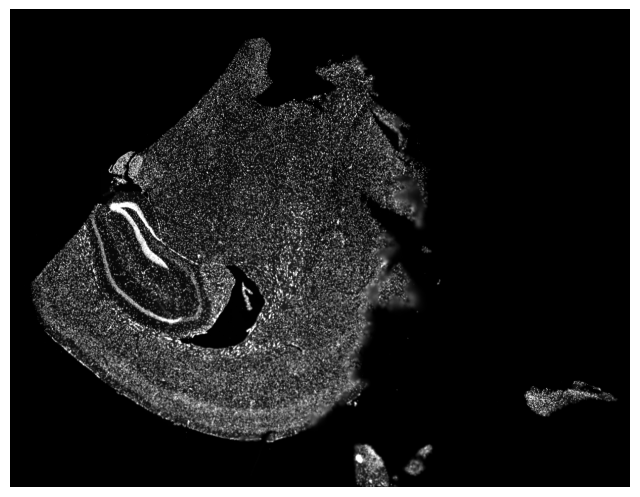

In [34]:
import tifffile as tiff
import numpy as np

BEST_Z = 3  # change to your best z plane
DISPLAY_LEVEL = 2

def read_ome_level_single_z(path, level_index=2, z_index=0):
    with tiff.TiffFile(path) as tif:
        series = tif.series[0]
        levels = getattr(series, "levels", None) or [series]
        level = levels[min(level_index, len(levels) - 1)]

        arr = np.asarray(level.asarray())
        axes = level.axes.upper()

    if axes == "ZYX":
        img = arr[z_index, :, :]
    elif "Z" in axes and "Y" in axes and "X" in axes:
        z_axis = axes.index("Z")
        arr_z = np.take(arr, z_index, axis=z_axis)

        axes_no_z = axes.replace("Z", "")
        y_axis = axes_no_z.index("Y")
        x_axis = axes_no_z.index("X")

        img = np.moveaxis(arr_z, [y_axis, x_axis], [0, 1])
    else:
        img = np.squeeze(arr)

    img = np.squeeze(img)

    if img.ndim != 2:
        raise ValueError(f"Expected 2D image after selecting Z={z_index}, got {img.shape}")

    return img

display_img = read_ome_level_single_z(
    MORPHOLOGY_PATH,
    level_index=DISPLAY_LEVEL,
    z_index=BEST_Z,
)

plt.figure(figsize=(8, 8))
plt.imshow(robust_rescale(display_img), cmap="gray", origin="upper")
plt.axis("off")
plt.show()

### Metadata-based initial overlay

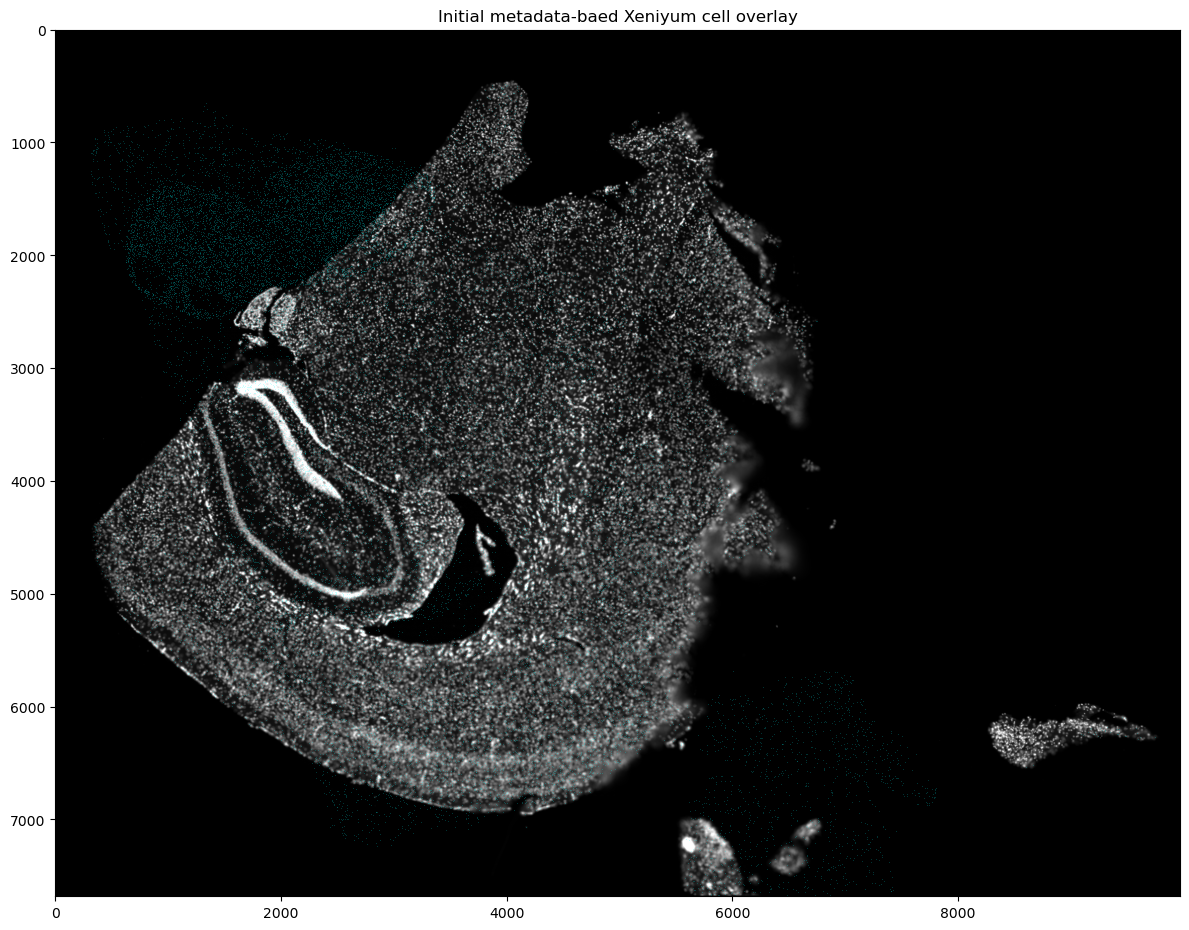

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/qc_initial_morphology_xenium_overlay_VS.png


In [35]:
native_transform = plaques_alignment.make_native_image_to_xenium_transform(
    COORDINATE_UNITS,
    float(ome_meta["physical_size_x"]),
    float(ome_meta["physical_size_y"]),
)

initial_cell_fullres_px = native_transform.inverse(xenium_xy[["x", "y"]].to_numpy(float))
adata.obsm["morphology_fullres_px_initial"] = initial_cell_fullres_px
initial_cell_fullres_px = plaques_alignment.fullres_to_level_points(
    initial_cell_fullres_px,
    tuple(ome_meta["fullres_shape_yx"]),
    (display_image_info["height_px"], display_image_info["width_px"])
)

plaques_alignment.plot_morphology_overlay(
    display_img, 
    initial_cell_fullres_px,
    "Initial metadata-baed Xeniyum cell overlay",
    WORKING_DIRECTORY / "qc_initial_morphology_xenium_overlay_VS.png",
)

### Optional manual landmark correction and save alignment

Using native OME metadata transform. Add at least 2 rows to manual_landmarks.csv to fit a similarity correction.


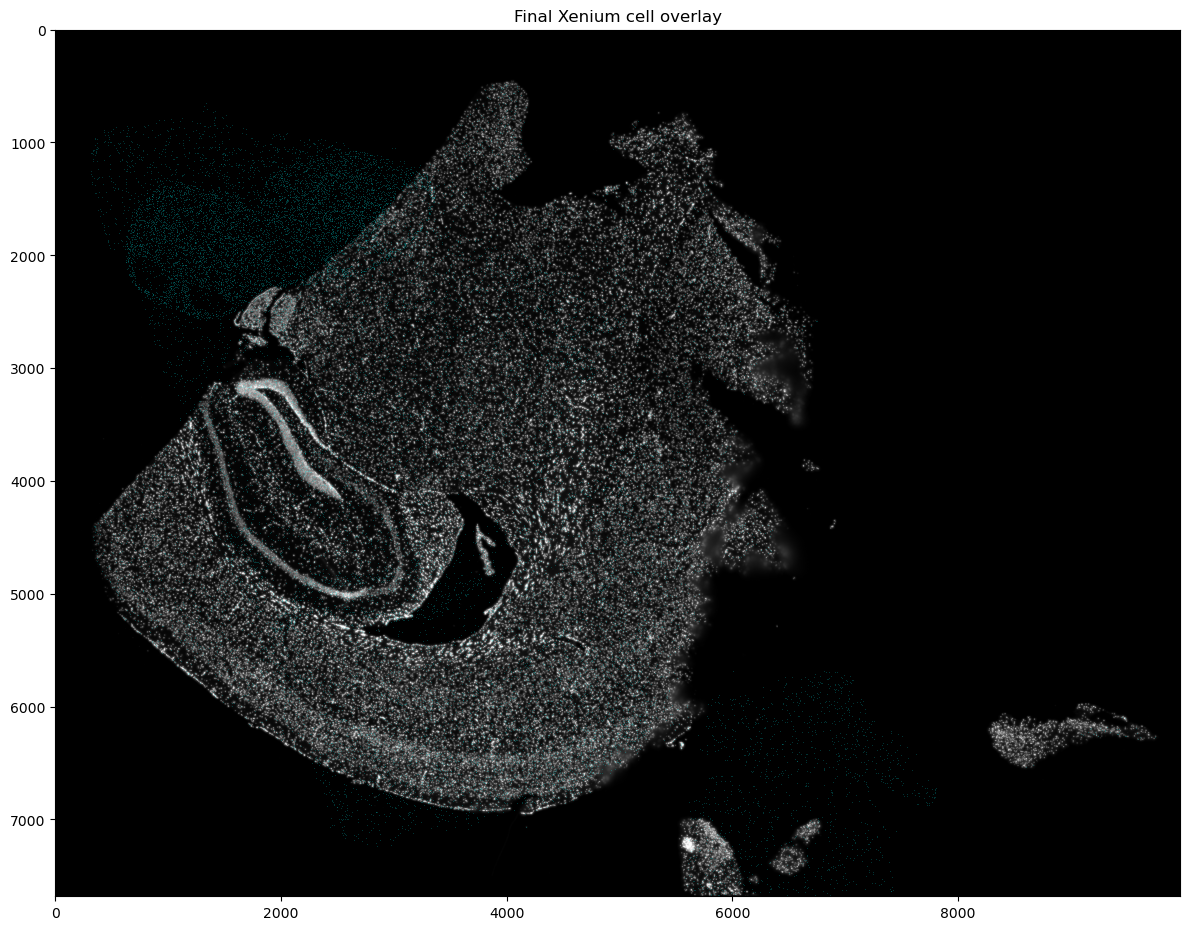

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/qc_final_morphology_xenium_overlay_VS.png
Saved aligned AnnData: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/05_scvi_with_morphology_alignment.h5ad


In [41]:
if not LANDMARK_TEMPLATE_PATH.exists():
    plaques_alignment.create_landmark_template(LANDMARK_TEMPLATE_PATH)
    print(f"Created landmark template: {LANDMARK_TEMPLATE_PATH}")
if not LANDMARK_PATH.exists():
    plaques_alignment.create_landmark_template(LANDMARK_PATH)
    print(f"Created blank manual landmark file: {LANDMARK_PATH}")

landmarks = plaques_alignment.load_manual_landmarks(LANDMARK_PATH)
image_to_xenium_transform, landmarks, landmark_transform_used = plaques_alignment.estimate_image_to_xenium_transform(
    native_transform, landmarks, LANDMARK_TRANSFORM_TYPE
)

final_cell_fullres_px = image_to_xenium_transform.inverse(xenium_xy[["x", "y"]].to_numpy(float))
adata.obsm["morphology_fullres_px"] = final_cell_fullres_px
final_cell_level_px = plaques_alignment.fullres_to_level_points(
    final_cell_fullres_px,
    tuple(ome_meta["fullres_shape_yx"]),
    (display_image_info["height_px"], display_image_info["width_px"]),
)

plaques_alignment.plot_morphology_overlay(
    display_img,
    final_cell_level_px,
    "Final Xenium cell overlay",
    WORKING_DIRECTORY / "qc_final_morphology_xenium_overlay_VS.png",
)

plaques_alignment.save_alignment_outputs(
    adata,
    ome_meta,
    coordinate_source,
    image_to_xenium_transform,
    landmark_transform_used,
    landmarks,
)



### Segment plaques and assign nearest plaques to cells

/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex/06_plaques_alignment.py:394: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(PLAQUE_OPENING_RADIUS_PX))
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex/06_plaques_alignment.py:395: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(PLAQUE_CLOSING_RADIUS_PX))
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex/06_plaques_alignment.py:396: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For

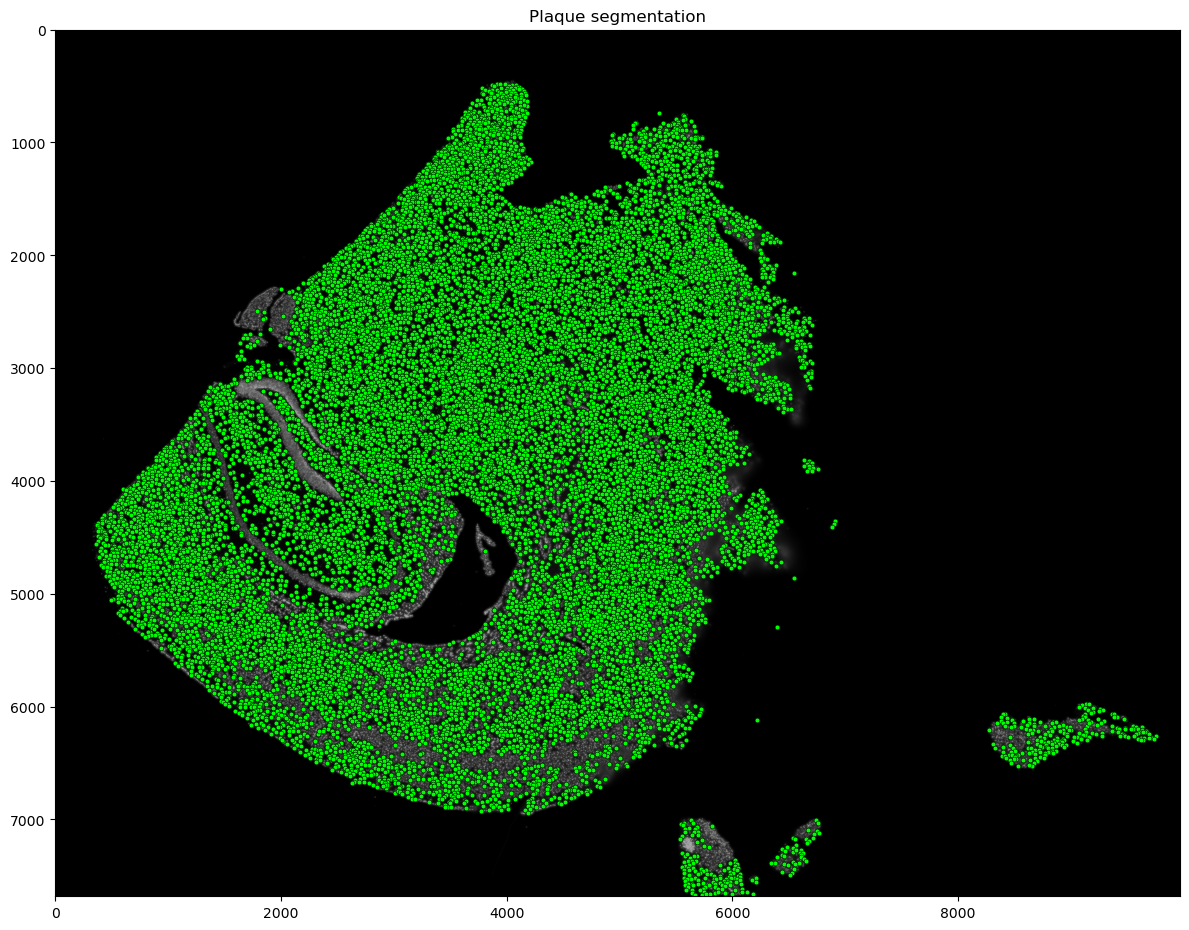

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/qc_plaque_segmentation.png
Saved 16307 segmented plaques to plaques_segmented.csv
Saved plaque-distance AnnData: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/05_scvi_with_plaque_distances.h5ad


In [56]:
if RUN_PLAQUE_SEGMENTATION:
    plaque_img, plaque_image_info = plaques_alignment.read_ome_level(
        MORPHOLOGY_PATH, 
        display_level,
        channel_index=PLAQUE_CHANNEL_INDEX,
        projection="max")
    plaque_level_info = {
        **display_level_info,
        "height_px": plaque_image_info["height_px"],
        "width_px": plaque_image_info["width_px"],
    }

    plaque_df, plaque_mask, plaque_labels = plaques_alignment.segment_plaques(
        plaque_img, image_to_xenium_transform, ome_meta, plaque_level_info
    )

    plaque_df.to_csv(WORKING_DIRECTORY / "plaques_segmented_VS.csv", index=False)
    np.save(WORKING_DIRECTORY / "plaque_mask_level_VS.npy", plaque_mask)
    np.save(WORKING_DIRECTORY / "plaque_labels_level_VS.npy", plaque_labels)
    plaques_alignment.plot_plaque_segmentation(
            plaque_img,
            plaque_mask,
            plaque_df,
            WORKING_DIRECTORY / "qc_plaque_segmentation.png",
        )

    plaques_alignment.assign_cells_to_plaques(adata, xenium_xy, plaque_df)
    plaque_df.to_csv(WORKING_DIRECTORY / "plaques_segmented_with_cell_counts.csv", index=False)
    adata.write_h5ad(PLAQUE_H5AD_PATH)

    print(f"Saved {len(plaque_df)} segmented plaques to plaques_segmented.csv")
    print(f"Saved plaque-distance AnnData: {PLAQUE_H5AD_PATH}")
else:
    print("RUN_PLAQUE_SEGMENTATION is False; skipping plaque segmentation.")
        
    

#### Load MapMyCells cluster annotations

This reads the MapMyCells CSV, joins annotations onto `adata.obs` by `cell_id`, and stores the joined labels with a `mapmycells_` prefix.

In [ ]:
MAPMYCELLS_CSV = Path(
    "/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/05_cluster_annotations/04_merged_adata_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1781207418912/04_merged_adata_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1781207418912.csv"
)

# MapMyCells CSVs include metadata comment lines beginning with '#'.
mapmycells = pd.read_csv(MAPMYCELLS_CSV, comment="#")
mapmycells = mapmycells.drop_duplicates("cell_id").set_index("cell_id")

annotation_cols = [
    "class_label",
    "class_name",
    "class_bootstrapping_probability",
    "subclass_label",
    "subclass_name",
    "subclass_bootstrapping_probability",
    "supertype_label",
    "supertype_name",
    "supertype_bootstrapping_probability",
    "cluster_label",
    "cluster_name",
    "cluster_alias",
    "cluster_bootstrapping_probability",
]

mapmycells_prefixed = mapmycells[annotation_cols].add_prefix("mapmycells_")

# Drop old versions of these columns before re-joining, so rerunning this cell is safe.
old_cols = [col for col in mapmycells_prefixed.columns if col in adata.obs.columns]
if old_cols:
    adata.obs = adata.obs.drop(columns=old_cols)

adata.obs = adata.obs.join(mapmycells_prefixed, how="left")

for col in adata.obs.columns:
    if col.startswith("mapmycells_") and not col.endswith("probability"):
        adata.obs[col] = adata.obs[col].astype("category")

matched = adata.obs["mapmycells_class_name"].notna().sum()
print(f"Loaded MapMyCells rows: {len(mapmycells):,}")
print(f"Matched cells in adata: {matched:,} / {adata.n_obs:,}")
print(adata.obs[["mapmycells_class_name", "mapmycells_subclass_name", "mapmycells_cluster_name"]].head())


#### Plot MapMyCells annotations and Leiden on UMAP

In [ ]:
# Use class/subclass on the main UMAP because cluster_name has many categories and creates a huge legend.
umap_colors = [
    "leiden",
    "mapmycells_class_name",
    "mapmycells_subclass_name",
]

sc.pl.umap(
    adata,
    color=[col for col in umap_colors if col in adata.obs.columns],
    frameon=False,
    wspace=0.45,
)

# Optional: cluster-level MapMyCells plot without a legend. Useful for structure, not for readable labels.
sc.pl.umap(
    adata,
    color="mapmycells_cluster_name",
    legend_loc="none",
    frameon=False,
    title="MapMyCells cluster_name",
)


#### Plot annotations directly on spatial tissue

In [ ]:
def get_spatial_xy_for_plot(adata):
    if {"x_centroid", "y_centroid"}.issubset(adata.obs.columns):
        return adata.obs[["x_centroid", "y_centroid"]].to_numpy(dtype=float)
    if "X_spatial" in adata.obsm:
        return np.asarray(adata.obsm["X_spatial"][:, :2], dtype=float)
    if "spatial" in adata.obsm:
        return np.asarray(adata.obsm["spatial"][:, :2], dtype=float)
    raise KeyError("Could not find x/y spatial coordinates in obs or obsm.")


def plot_spatial_categorical(
    adata,
    color,
    s=0.25,
    alpha=0.85,
    legend=True,
    max_legend_categories=45,
    invert_y=True,
    save=None,
):
    xy = get_spatial_xy_for_plot(adata)
    values = adata.obs[color].astype("category")
    codes = values.cat.codes.to_numpy()
    categories = list(values.cat.categories)
    valid = codes >= 0

    fig, ax = plt.subplots(figsize=(8, 8))
    cmap = plt.get_cmap("tab20", max(len(categories), 1))
    ax.scatter(
        xy[valid, 0],
        xy[valid, 1],
        c=codes[valid],
        cmap=cmap,
        vmin=-0.5,
        vmax=max(len(categories) - 0.5, 0.5),
        s=s,
        alpha=alpha,
        linewidths=0,
        rasterized=True,
    )
    ax.set_title(color)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    if invert_y:
        ax.invert_yaxis()

    if legend and len(categories) <= max_legend_categories:
        from matplotlib.lines import Line2D

        handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=str(cat),
                markerfacecolor=cmap(i),
                markersize=5,
            )
            for i, cat in enumerate(categories)
        ]
        ax.legend(
            handles=handles,
            bbox_to_anchor=(1.04, 1),
            loc="upper left",
            frameon=False,
            fontsize=7,
        )
    elif legend:
        ax.text(
            0.01,
            0.01,
            f"{len(categories)} categories; legend hidden",
            transform=ax.transAxes,
            fontsize=8,
            va="bottom",
        )

    fig.tight_layout()
    if save is not None:
        fig.savefig(save, dpi=300, bbox_inches="tight")
        print(f"Saved: {save}")
    plt.show()


In [ ]:
plot_spatial_categorical(
    adata,
    "mapmycells_class_name",
    s=0.2,
    save=WORKING_DIRECTORY / "spatial_mapmycells_class_name.png",
)

plot_spatial_categorical(
    adata,
    "mapmycells_subclass_name",
    s=0.2,
    save=WORKING_DIRECTORY / "spatial_mapmycells_subclass_name.png",
)

plot_spatial_categorical(
    adata,
    "leiden",
    s=0.2,
    save=WORKING_DIRECTORY / "spatial_leiden.png",
)

# Optional cluster-level tissue plot. Legend is hidden by default because there are usually many clusters.
plot_spatial_categorical(
    adata,
    "mapmycells_cluster_name",
    s=0.2,
    legend=False,
    save=WORKING_DIRECTORY / "spatial_mapmycells_cluster_name.png",
)


#### Save h5ad with MapMyCells annotations

In [ ]:
ANNOTATED_H5AD_PATH = WORKING_DIRECTORY / "05_scvi_with_mapmycells_annotations.h5ad"
adata.write_h5ad(ANNOTATED_H5AD_PATH)
print(f"Saved annotated AnnData: {ANNOTATED_H5AD_PATH}")
